The Poisson HPD example in lecture notes:

# Poisson likelihood + Gamma prior

Let $X_1,\dots,X_n \stackrel{\text{iid}}{\sim}\text{Poisson}(\lambda)$ and use the conjugate prior

$$
\lambda \sim \text{Gamma}(a,\; b) \quad\text{(shape \(a\), scale \(b\))}.
$$

The likelihood is

$$
L(\lambda\mid x)=\prod_{i=1}^n e^{-\lambda}\frac{\lambda^{x_i}}{x_i!}\ \propto\ e^{-n\lambda}\lambda^{\sum x}.
$$

## Posterior

The posterior is Gamma with

$$
k \;=\; a+\sum_{i=1}^n x_i,\qquad
\text{scale } \theta \;=\; \frac{1}{\,n+1/b\,},\qquad
\text{rate } r \;=\; \frac{1}{\theta}= n+\frac{1}{b}.
$$

So the **posterior pdf** is

$$
\boxed{\;\pi(\lambda\mid x)=
\frac{r^{\,k}}{\Gamma(k)}\,\lambda^{k-1}e^{-r\lambda},\qquad \lambda>0\;}
$$

with CDF $F(\lambda\mid x)=\text{GammaCDF}(\lambda;\,k,\text{rate }r)$.

For the book’s numbers $a=b=1,\ n=10,\ \sum x=6$:

$$
k=7,\quad r=11,\quad \text{mode}=\frac{k-1}{r}=\frac{6}{11}\approx 0.545.
$$

# HPD (Shortest) $ (1-\alpha)$ Credible Interval

The HPD region is the shortest interval that contains posterior probability $1-\alpha$. For a **unimodal** posterior (true here because $k>1$), the HPD set is the super-level set of the posterior density:

$$
C_{\text{HPD}}(x)=\{\lambda:\ \pi(\lambda\mid x)\ge c\},
$$

for a threshold $c>0$ chosen so that

$$
\int_{\{\lambda:\ \pi(\lambda\mid x)\ge c\}} \pi(\lambda\mid x)\,d\lambda \;=\; 1-\alpha.
$$

Equivalently, the HPD interval $[\,\lambda_L,\lambda_U\,]$ is characterized by the **two equations**:

1. **Equal-density endpoints (highest-density contour):**

$$
\pi(\lambda_L\mid x)=\pi(\lambda_U\mid x)\quad\iff\quad
\lambda_L^{\,k-1}e^{-r\lambda_L}=\lambda_U^{\,k-1}e^{-r\lambda_U}.
$$

Taking logs,

$$
(k-1)\big(\ln\lambda_L-\ln\lambda_U\big)=r(\lambda_L-\lambda_U).
$$

2. **Mass constraint (coverage):**

$$
F(\lambda_U\mid x)-F(\lambda_L\mid x)=1-\alpha.
$$

These two equations determine $\lambda_L<\text{mode}<\lambda_U$ uniquely (solve numerically).

## Numbers for the example (90% HPD, $\alpha=0.10$)

Solving the system for $k=7,\ r=11$ gives approximately

$$
\boxed{\lambda_L \approx 0.253,\qquad \lambda_U \approx 1.005,}
$$

which matches the book’s interval. (The equal-tail 90% credible interval is slightly wider and shifted to the right due to posterior skew.)

# How to compute (two equivalent practical routes)

* **Threshold (super-level set) method:** find $c$ so that the posterior mass of $\{\lambda:\pi(\lambda\mid x)\ge c\}$ is $1-\alpha$. This involves (i) solving $\pi(\lambda)=c$ for the two roots $\lambda_L(c),\lambda_U(c)$ (they straddle the mode), then (ii) adjusting $c$ until $F(\lambda_U)-F(\lambda_L)=1-\alpha$.
* **Shortest-length method:** minimize $\lambda_U-\lambda_L$ subject to $F(\lambda_U)-F(\lambda_L)=1-\alpha$. The first-order condition for optimality is exactly the **equal-density** condition $\pi(\lambda_L)=\pi(\lambda_U)$.

Either way uses the **posterior pdf above** (Gamma with $k=7$, $r=11$) and the **Gamma CDF** for the probability constraint.



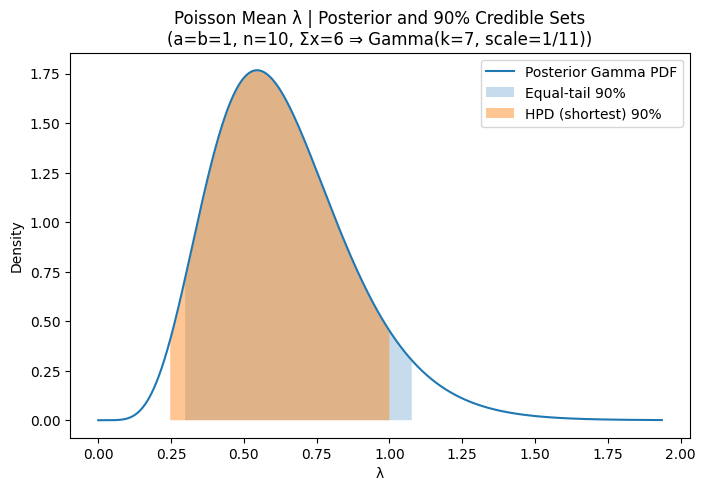

             Interval  Lower  Upper  Length
0      Equal-tail 90%  0.299  1.077   0.778
1  HPD (shortest) 90%  0.247  1.000   0.753


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st

# Posterior params
n = 10
sum_x = 6
a = 1
b = 1
shape = a + sum_x
rate = n + 1/b
scale = 1.0 / rate

# Grid
x_max = st.gamma.ppf(0.9999, a=shape, scale=scale)
x = np.linspace(0, x_max, 4000)
pdf = st.gamma.pdf(x, a=shape, scale=scale)
cdf = st.gamma.cdf(x, a=shape, scale=scale)

alpha = 0.10
coverage = 1 - alpha

# Equal-tail
et_lower = st.gamma.ppf(alpha/2, a=shape, scale=scale)
et_upper = st.gamma.ppf(1 - alpha/2, a=shape, scale=scale)

# Shortest (HPD) via sliding window
best_len = np.inf
hpd_lower = None
hpd_upper = None
for i in range(len(x)):
    target = cdf[i] + coverage
    if target >= 1:
        break
    j = np.searchsorted(cdf, target, side='left')
    if j < len(x):
        length = x[j] - x[i]
        if length < best_len:
            best_len = length
            hpd_lower, hpd_upper = x[i], x[j]

# Plot
plt.figure(figsize=(8,5))
plt.plot(x, pdf, label="Posterior Gamma PDF")
xx = np.linspace(et_lower, et_upper, 400)
plt.fill_between(xx, st.gamma.pdf(xx, a=shape, scale=scale), alpha=0.25, label="Equal-tail 90%")
xx = np.linspace(hpd_lower, hpd_upper, 400)
plt.fill_between(xx, st.gamma.pdf(xx, a=shape, scale=scale), alpha=0.45, label="HPD (shortest) 90%")
plt.title("Poisson Mean λ | Posterior and 90% Credible Sets\n(a=b=1, n=10, Σx=6 ⇒ Gamma(k=7, scale=1/11))")
plt.xlabel("λ")
plt.ylabel("Density")
plt.legend()
plt.show()

# Numbers
df = pd.DataFrame({
    "Interval": ["Equal-tail 90%", "HPD (shortest) 90%"],
    "Lower": [et_lower, hpd_lower],
    "Upper": [et_upper, hpd_upper],
    "Length": [et_upper - et_lower, hpd_upper - hpd_lower]
}).round(3)

try:
    from caas_jupyter_tools import display_dataframe_to_user
    display_dataframe_to_user("Poisson posterior credible sets (n=10, sum x=6)", df)
except Exception:
    print(df)
